#NFL Team Performance Analysis: Passing vs Rushing Efficiency and Wins
##Holden Roth - April 4th, 2026


In this personal project, I am analyzing 20 years of recent NFL team data. I wanted to discover which offensive statistic was more influential on a team's yearly win total: passing efficiency or rushing efficiency. While the league is filled with star-studded wide receivers like Ja'Marr Chase, Ceedee Lamb, and Puka Nacua, who are all flashy and fun to watch, rushing is still a crucial part of the game that cannot be neglected. With the current era of the NFL being pass-first, having a strong and efficient rushing attack is becoming increasingly rare. But the question becomes, does that make it increasingly valuable? Since teams are more focused on passing, does that make having a strong run game a major advantage? These questions are examined and answered in this data analysis focusing on the variables *pass_net_yds_per_att* and *rush_yds_per_att*, which I will interchangably refer to as *passing efficiency* and *rushing efficiency*.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
df = pd.read_csv('/team_stats_2003_2023.csv')

## Preview
Now that I have input the dataset and relevant tools I will be using, let's take a glance at what the data looks like, examining the first and last few rows to preview:

In [2]:
pd.concat([df.head(3), df.tail(3)])

,year,team,wins,losses,win_loss_perc,points,points_opp,points_diff,mov,g,...,rush_td,rush_yds_per_att,rush_fd,penalties,penalties_yds,pen_fd,score_pct,turnover_pct,exp_pts_tot,ties
0,2003,New England Patriots,14,2,0.875,348,238,110,6.9,16,...,9,3.4,91,111,998,26,27.9,11.3,-136.51,NaN
1,2003,Miami Dolphins,10,6,0.625,311,261,50,3.1,16,...,14,3.7,99,103,913,22,28.1,17.2,-177.92,NaN
2,2003,Buffalo Bills,6,10,0.375,243,279,-36,-2.3,16,...,13,3.9,96,106,891,22,21.9,17.6,-230.07,NaN
669,2023,Los Angeles Rams,10,7,0.588,404,377,27,1.6,17,...,18,4.3,110,89,720,35,41.1,9.2,133.32,NaN
670,2023,Seattle Seahawks,9,8,0.529,364,402,-38,-2.2,17,...,11,4.1,93,111,954,35,38.8,8.4,62.33,NaN
671,2023,Arizona Cardinals,4,13,0.235,330,455,-125,-7.4,17,...,17,5.0,127,101,859,30,35.0,9.4,-2.99,NaN


## Data Cleaning
Before I begin analysis, I'll check if the data has any missing values.

In [3]:
df.isnull().sum()

,0
year,0
team,0
wins,0
losses,0
win_loss_perc,0
points,0
points_opp,0
points_diff,0
mov,320
g,0


There are numerous empty cells in the 'ties' and 'mov' columns. I will fix the 'ties' column first. Looking at the full dataset, teams with 0 ties either represent this with an empty cell or display the value '0.0'. For consistency, I will replace the empty cells with '0.0', so that all teams with 0 ties display '0.0'.

In [4]:
df['ties'] = df['ties'].fillna(0.0)

The 'mov' column is margin of victory, meaning the average margin of victory over the course of the season. This can actually be manually calcualted within the dataset itself, by dividing point differential *(points_diff)* by number of games played *(g)*. I will use this calculation to populate the entire 'mov' column.

In [5]:
df['mov'] = round(df['points_diff'] / df['g'], 1)

## Description
Now that the data is cleaned with no empty cells, let's see a description:

In [6]:
pd.set_option('display.max_columns', None)
round(df.describe(), 1)

,year,wins,losses,win_loss_perc,points,points_opp,points_diff,mov,g,total_yards,plays_offense,yds_per_play_offense,turnovers,fumbles_lost,first_down,pass_cmp,pass_att,pass_yds,pass_td,pass_int,pass_net_yds_per_att,pass_fd,rush_att,rush_yds,rush_td,rush_yds_per_att,rush_fd,penalties,penalties_yds,pen_fd,score_pct,turnover_pct,exp_pts_tot,ties
count,672.0,672.0,672.0,672.0,672.0,672.0,672.0,672.0,672.0,672.0,672.0,672.0,672.0,672.0,672.0,672.0,672.0,672.0,672.0,672.0,672.0,672.0,672.0,672.0,672.0,672.0,672.0,672.0,672.0,672.0,672.0,672.0,672.0,672.0
mean,2013.0,8.1,8.1,0.5,358.6,358.6,0.0,0.0,16.1,5463.9,1021.9,5.3,24.7,10.1,314.4,339.3,546.9,3617.0,23.6,14.6,6.2,186.7,437.8,1846.9,13.5,4.2,99.8,101.5,849.5,27.9,34.1,12.6,-35.9,0.0
std,6.1,3.1,3.1,0.2,72.1,57.9,100.7,6.2,0.3,628.2,51.2,0.5,6.6,3.5,38.5,50.6,61.8,618.1,7.6,4.8,0.8,31.2,51.8,343.2,5.2,0.4,20.8,16.1,146.2,7.3,6.7,3.2,120.6,0.2
min,2003.0,0.0,0.0,0.0,168.0,201.0,-261.0,-16.3,16.0,3587.0,865.0,3.9,8.0,2.0,191.0,204.0,358.0,1898.0,7.0,2.0,4.1,96.0,304.0,1129.0,2.0,3.1,53.0,55.0,415.0,9.0,16.4,4.0,-358.3,0.0
25%,2008.0,6.0,6.0,0.4,305.0,316.8,-75.0,-4.6,16.0,5030.2,990.0,5.0,20.0,8.0,288.0,303.0,506.8,3156.2,18.0,11.0,5.7,163.0,401.0,1606.0,10.0,3.9,84.0,91.0,751.8,23.0,29.2,10.2,-124.0,0.0
50%,2013.0,8.0,8.0,0.5,359.0,356.5,-1.0,-0.1,16.0,5467.5,1019.0,5.3,24.0,10.0,313.0,339.0,546.0,3592.5,23.0,14.0,6.1,186.0,433.5,1810.0,13.0,4.2,98.0,102.0,852.5,27.0,33.9,12.4,-41.0,0.0
75%,2018.0,10.0,10.0,0.6,406.0,398.0,75.2,4.6,16.0,5900.2,1053.0,5.7,29.0,12.0,340.0,372.0,590.0,4047.5,28.0,18.0,6.8,208.0,472.0,2047.2,17.0,4.5,112.2,112.0,941.2,33.0,38.8,14.8,49.8,0.0
max,2023.0,16.0,16.0,1.0,606.0,519.0,315.0,19.7,17.0,7474.0,1191.0,6.8,46.0,26.0,444.0,499.0,751.0,5444.0,55.0,32.0,8.5,293.0,618.0,3296.0,32.0,5.5,188.0,163.0,1358.0,50.0,52.7,25.0,298.1,1.0


A few things that I personally found interesting from the data description:
- For yards per play on offense *(yds_per_play_offense)*, the data had less variance than I expected. The average yards per play was 5.3, with a standard deviation of only 0.5. Additionally, 50% of the data in this column was between 5.0 and 5.7, which was surprisingly consistent to me.
- No team has had more than one tie in a season over this 20-year span of data. In fact, after doing further research, I found that no team has tied twice or more in a season since overtime rules were introduced in 1974.
- The mean number of penalties in a season was 101.5. This is much higher than I anticipated.

## Correlation
Now let's look at a correlation table with our relevant variables: *'wins'*, *'pass_net_yds_per_att'*, and *'rush_yds_per_att'*. I will also include *'turnovers'* and *'points_diff'* to create a more complete table with other simple correlations.

In [7]:
corr_cols = ['wins', 'pass_net_yds_per_att', 'rush_yds_per_att', 'turnovers', 'points_diff']
df[corr_cols].corr()

,wins,pass_net_yds_per_att,rush_yds_per_att,turnovers,points_diff
wins,1.000000,0.615580,0.122127,-0.499764,0.908735
pass_net_yds_per_att,0.615580,1.000000,0.131239,-0.389215,0.665717
rush_yds_per_att,0.122127,0.131239,1.000000,-0.227521,0.164288
turnovers,-0.499764,-0.389215,-0.227521,1.000000,-0.495914
points_diff,0.908735,0.665717,0.164288,-0.495914,1.000000


- The correlation between passing efficiency and wins is 0.6156, which is a strong positive correlation.
- The correlation between rushing efficiency and wins is only 0.1221, which is a weak positive correlation.
### Takeaway:
Having an efficient passing offense has a much higher correlation with winning games than having an efficient rushing offense. In fact, the efficiency of the run game actually has very little correlation with winning games at all.


## Scatterplots:


Text(0, 0.5, 'Wins')

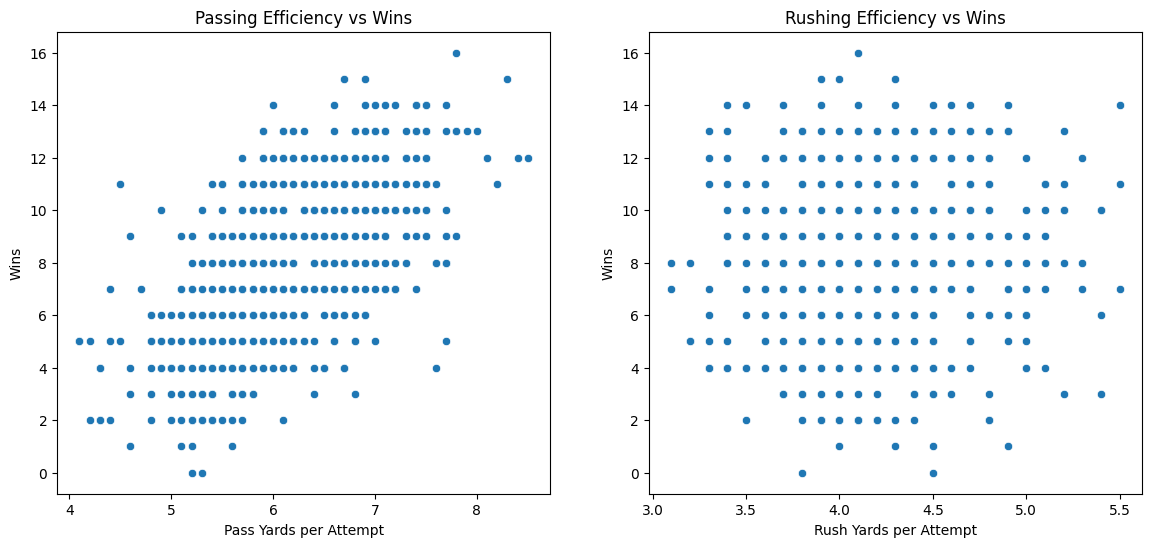

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))

sns.scatterplot(data=df, x='pass_net_yds_per_att', y='wins', ax=axes[0])
axes[0].set_title('Passing Efficiency vs Wins')
axes[0].set_xlabel('Pass Yards per Attempt')
axes[0].set_ylabel('Wins')

sns.scatterplot(data=df, x='rush_yds_per_att', y='wins', ax=axes[1])
axes[1].set_title('Rushing Efficiency vs Wins')
axes[1].set_xlabel('Rush Yards per Attempt')
axes[1].set_ylabel('Wins')

The scatterplots visually confirm the findings from the correlation analysis. Passing efficiency has a clear upward trend with wins, while rushing efficiency seems to have little to no impact on number of wins.

## Regression Model:
Now, let's create a regression model to see if we can accurately predict a team's number of wins based on either passing or rushing efficiency.

In [9]:
X_pass = df[['pass_net_yds_per_att']]
X_rush = df[['rush_yds_per_att']]
y = df['wins']

#Split data into training data and testing data
X_pass_train, X_pass_test, y_pass_train, y_pass_test = train_test_split(X_pass, y, test_size=0.2, random_state=42)
X_rush_train, X_rush_test, y_rush_train, y_rush_test = train_test_split(X_rush, y, test_size=0.2, random_state=42)

#Create the regression models and train them
pass_model = LinearRegression()
pass_model.fit(X_pass_train, y_pass_train)

rush_model = LinearRegression()
rush_model.fit(X_rush_train, y_rush_train)

#See if it is accurate using the test data
pass_predictions = pass_model.predict(X_pass_test)
rush_predictions = rush_model.predict(X_rush_test)

print(f"Passing coefficient: {pass_model.coef_[0]:.3f}")
print(f"Rushing coefficient: {rush_model.coef_[0]:.3f}")

print(f"Passing intercept: {pass_model.intercept_:.3f}")
print(f"Rushing intercept: {rush_model.intercept_:.3f}")

print(f"Passing Model R² Score: {r2_score(y_pass_test, pass_predictions):.3f}")
print(f"Rushing Model R² Score: {r2_score(y_rush_test, rush_predictions):.3f}")

Passing coefficient: 2.383
Rushing coefficient: 0.644
Passing intercept: -6.777
Rushing intercept: 5.296
Passing Model R² Score: 0.466
Rushing Model R² Score: 0.028


### Interpretation
- For each additional passing yard per attempt, wins increases by 2.383
- For each additional rushing yard per attempt, wins increases by 0.644
- Passing efficiency explains 46.6% of the variation in wins
- Rushing efficiency explains only 2.8% of the variation in wins

Once again, the findings show passing efficiency has a much more significant effect on wins than rushing efficiency.

We can also make an equation to predict wins based off of either variable. In this case, I will do passing, and use the coefficient and intercept values. The equation would look like:

**Predicted Wins** = (2.383 x **pass yards per attempt**) - 6.777

### Test
Let's see if the model works with an example from the Data. I am a Detroit Lions fan, so I am going to pick the 2023 Detroit Lions data. Their pass_net_yds_per_att was 6.9.

In [10]:
lions_predicted_wins = pass_model.coef_[0] * 6.9 + pass_model.intercept_
print(f"Predicted wins: {lions_predicted_wins:.1f}")

Predicted wins: 9.7


The model predicted 9.7 wins for the 2023 Detroit Lions, compared to their actual 12 wins. This is not on the dot, but is still in the ballpark of a good season from a football team. This demonstrates the limitation of a single variable model. There are many other factors that impact wins, including defense, injuries, strenght of schedule, etc. For a single variable, this is a solid indicator of a team's success.

# Conclusion
<u>**Question:**</u> I set out to investigate whether passing or rushing efficiency is a better indicator of a winning team in the NFL. With the growing popularity of passing, is a strong run game more valuable? Which should teams focus on more?

<u>**Findings:**</u> The findings were all very consistent. Passing efficiency showed much stronger correlation with wins than rushing efficiency (0.62 vs 0.12), explained 47% of win variance vs only 3% for rushing, and had a coefficient of 2.4 wins per yard vs 0.6 for rushing.

<u>**Model Test:**</u>
Demonstrated with the 2023 Detroit Lions, the model predicted 9.7 wins vs their actual 12, showing the model works reasonably well but that wins are influenced by other factors as well.

<u>**Limitations:**</u>
A single variable model does not account for the numerous other influences, such as defense, injuries, strenght of schedule, and more. A future improvement could be combining multiple variables into one model.

<u>**Conclusion:**</u>
In the modern NFL, teams should prioritize building an efficient passing attack as opposed to an efficient rushing attack.